In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
heart=pd.read_csv('heart_disease_cleaned.csv')
heart

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.00,233.0,True,lv hypertrophy,150.00,False,2.300,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.00,286.0,False,lv hypertrophy,108.00,True,1.500,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.00,229.0,False,lv hypertrophy,129.00,True,2.600,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.00,250.0,False,normal,187.00,False,3.500,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.00,204.0,False,lv hypertrophy,172.00,False,1.400,upsloping,0.0,normal,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
914,916,54,Female,VA Long Beach,asymptomatic,127.00,333.0,True,st-t abnormality,154.00,False,0.000,flat,0.0,normal,1
915,917,62,Male,VA Long Beach,typical angina,143.06,139.0,False,st-t abnormality,119.94,True,2.042,flat,0.0,reversable defect,0
916,918,55,Male,VA Long Beach,asymptomatic,122.00,223.0,True,st-t abnormality,100.00,False,0.000,flat,1.0,fixed defect,2
917,919,58,Male,VA Long Beach,asymptomatic,150.81,385.0,True,lv hypertrophy,110.63,True,2.181,flat,0.0,reversable defect,0


Exploratory Data Analysis (EDA)

In [3]:
heart.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 919 entries, 0 to 918
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        919 non-null    int64  
 1   age       919 non-null    int64  
 2   sex       919 non-null    object 
 3   dataset   919 non-null    object 
 4   cp        919 non-null    object 
 5   trestbps  919 non-null    float64
 6   chol      919 non-null    float64
 7   fbs       919 non-null    bool   
 8   restecg   919 non-null    object 
 9   thalch    919 non-null    float64
 10  exang     919 non-null    bool   
 11  oldpeak   919 non-null    float64
 12  slope     919 non-null    object 
 13  ca        919 non-null    float64
 14  thal      919 non-null    object 
 15  num       919 non-null    int64  
dtypes: bool(2), float64(5), int64(3), object(6)
memory usage: 102.4+ KB


In [4]:
heart.columns

Index(['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs',
       'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'],
      dtype='object')

In [5]:
heart.describe(include='all')

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
count,919.000000,919.000000,919,919,919,919.000000,919.000000,919,919,919.000000,919,919.000000,919,919.000000,919,919.000000
unique,NaN,NaN,2,4,4,NaN,NaN,2,3,NaN,2,NaN,3,NaN,3,NaN
top,NaN,NaN,Male,Cleveland,asymptomatic,NaN,NaN,False,normal,NaN,False,NaN,flat,NaN,reversable defect,NaN
freq,NaN,NaN,725,304,496,NaN,NaN,781,551,NaN,533,NaN,527,NaN,504,NaN
mean,460.180631,53.509249,NaN,NaN,NaN,132.704853,200.791393,NaN,NaN,136.815734,NaN,0.973408,NaN,0.501632,NaN,0.993471
std,265.693391,9.429689,NaN,NaN,NaN,18.070335,109.213597,NaN,NaN,25.371260,NaN,1.120490,NaN,0.786423,NaN,1.141398
min,1.000000,28.000000,NaN,NaN,NaN,80.000000,0.000000,NaN,NaN,60.000000,NaN,-2.600000,NaN,0.000000,NaN,0.000000
25%,230.500000,47.000000,NaN,NaN,NaN,120.000000,178.500000,NaN,NaN,120.000000,NaN,0.000000,NaN,0.000000,NaN,0.000000
50%,460.000000,54.000000,NaN,NaN,NaN,130.000000,224.000000,NaN,NaN,138.000000,NaN,0.800000,NaN,0.000000,NaN,1.000000
75%,689.500000,60.000000,NaN,NaN,NaN,141.210000,268.000000,NaN,NaN,156.000000,NaN,1.900000,NaN,1.000000,NaN,2.000000


In [6]:
heart.shape

(919, 16)

Dealing with age column

In [7]:
heart['age'].min(), heart['age'].max(), heart['age'].mean()

(28, 77, np.float64(53.50924918389554))

In [8]:
heart['age'].describe()

count    919.000000
mean      53.509249
std        9.429689
min       28.000000
25%       47.000000
50%       54.000000
75%       60.000000
max       77.000000
Name: age, dtype: float64

<Axes: xlabel='age', ylabel='Count'>

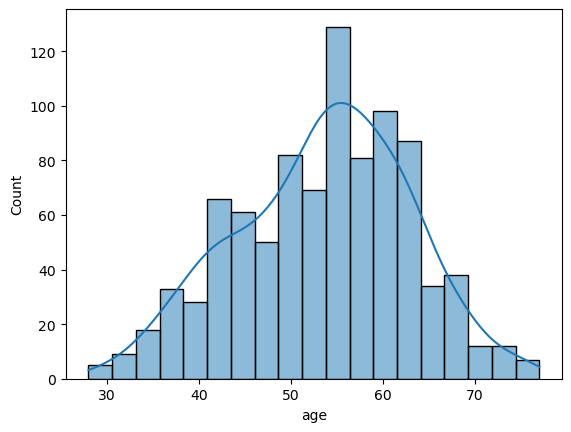

In [9]:
sns.histplot(heart['age'], kde=True)

Mean: 53.50924918389554
Median: 54.0
Mode: 54


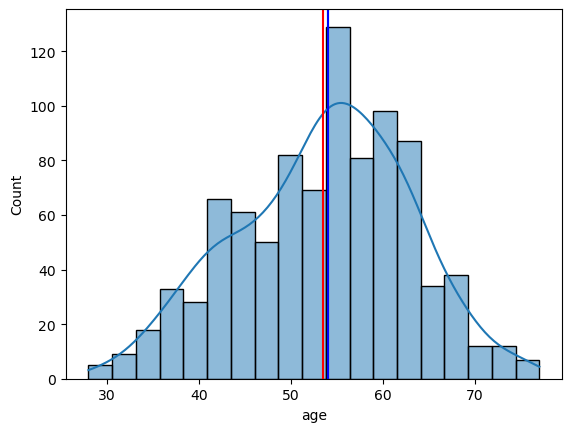

In [10]:
#plot the mean, median, mode of age column using sns
#axvline - axes verticle line

sns.histplot(heart['age'], kde=True)
plt.axvline(heart['age'].mean(), color='red')
plt.axvline(heart['age'].median(), color='green')
plt.axvline(heart['age'].mode()[0], color='blue')

#print the value of mean, median, mode of age column
print('Mean:', heart['age'].mean())
print('Median:', heart['age'].median())
print('Mode:', heart['age'].mode()[0])

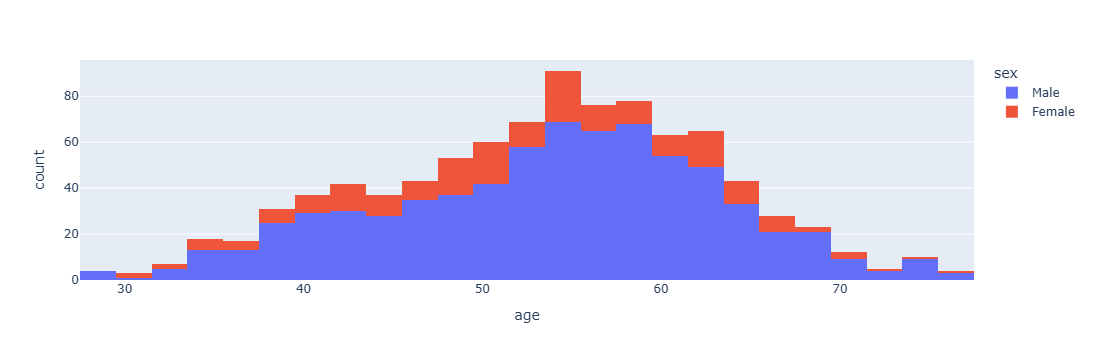

In [11]:
#plot the histogram of age column using plotly and coloring this by sex

fig=px.histogram(data_frame=heart, x='age', color='sex')
fig.show()

In [12]:
male_count=725
female_count=194
total_count=male_count + female_count

#calculate percentage
male_percentage= (male_count/total_count)*100
female_percentage= (female_count/total_count)*100

#display results
print(f'Male percentage in the data: {male_percentage:.2f}%')
print(f'Female percentage in the data: {female_percentage:.2f}%')

#difference
difference_percentage= ((male_count - female_count)/ female_count)*100
print(f'Males are {difference_percentage:.2f}% more than females in the data')

Male percentage in the data: 78.89%
Female percentage in the data: 21.11%
Males are 273.71% more than females in the data


In [13]:
fig=px.histogram(data_frame=heart, x='age', color='cp')
fig.show()

Dealing with sex columns

In [14]:
heart['sex'].value_counts()

sex
Male      725
Female    194
Name: count, dtype: int64

In [15]:
heart.groupby('sex')['age'].value_counts()

sex     age
Female  54     15
        51     11
        62     10
        43      9
        48      9
               ..
Male    77      2
        28      1
        31      1
        33      1
        76      1
Name: count, Length: 91, dtype: int64

Dealing with dataset column

In [16]:
fig=px.bar(heart, x='dataset', color='sex')
fig.show()

print(heart.groupby('sex')['dataset'].value_counts())

sex     dataset      
Female  Cleveland         97
        Hungary           81
        Switzerland       10
        VA Long Beach      6
Male    Hungary          212
        Cleveland        207
        VA Long Beach    193
        Switzerland      113
Name: count, dtype: int64


In [17]:
#make a plot of age column using plotly and colring this by dataset column
fig = px.histogram(data_frame=heart, x='age', color='dataset')
fig.show()
#histogram needs data_frame not data

print(f'Mean of the Dataset: {heart.groupby('dataset')['age'].mean()}')
print('**'*8)
print(f'Median of the Dataset: {heart.groupby('dataset')['age'].median()}')
print('**'*8)
print(f'Mode of the Dataset: {heart.groupby('dataset')['age'].agg(pd.Series.mode)}')
#there is no mode T-T using mode from pd.Series 

Mean of the Dataset: dataset
Cleveland        54.351974
Hungary          47.894198
Switzerland      55.317073
VA Long Beach    59.371859
Name: age, dtype: float64
****************
Median of the Dataset: dataset
Cleveland        55.5
Hungary          49.0
Switzerland      56.0
VA Long Beach    60.0
Name: age, dtype: float64
****************
Mode of the Dataset: dataset
Cleveland              58
Hungary                54
Switzerland            61
VA Long Beach    [62, 63]
Name: age, dtype: object


Dealing with cp column

In [18]:
heart['cp'].value_counts()

cp
asymptomatic       496
non-anginal        203
atypical angina    174
typical angina      46
Name: count, dtype: int64

<Axes: xlabel='cp', ylabel='count'>

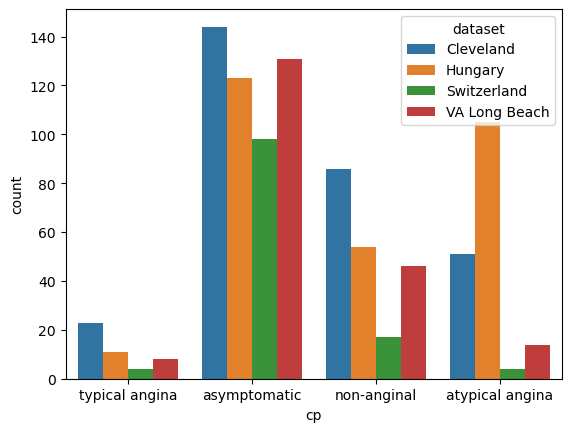

In [20]:
sns.countplot(heart, x='cp', hue='dataset')

In [21]:
heart=heart[heart['trestbps']!=0]

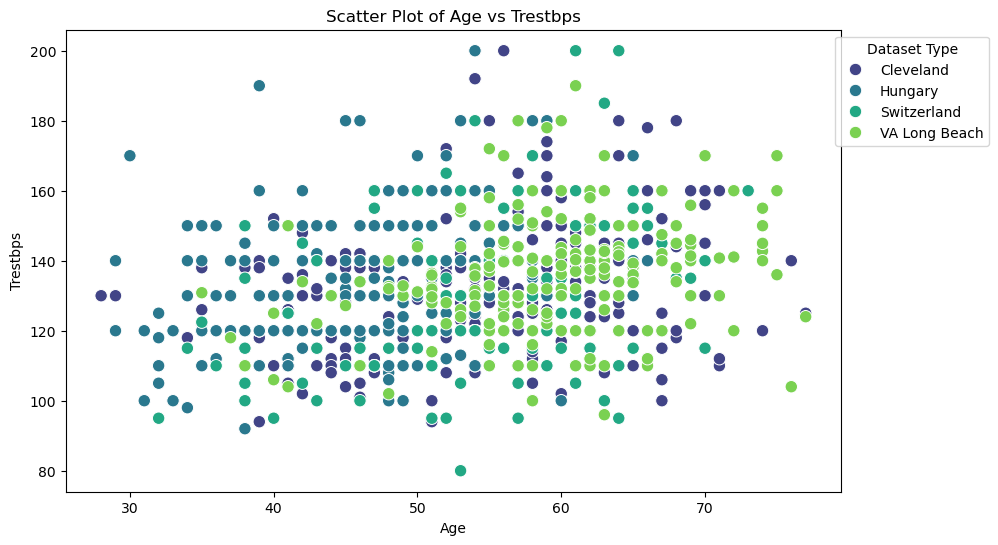

In [22]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=heart, x='age', y='trestbps', hue='dataset', palette='viridis', s=80)

plt.title('Scatter Plot of Age vs Trestbps')
plt.xlabel('Age')
plt.ylabel('Trestbps')
plt.legend(title='Dataset Type', loc='upper right', bbox_to_anchor=(1.2,1))
plt.show()

Distribution of cholestrol

<Axes: title={'center': 'Distribution of Cholestrol by sex'}, xlabel='Cholestrol', ylabel='count'>

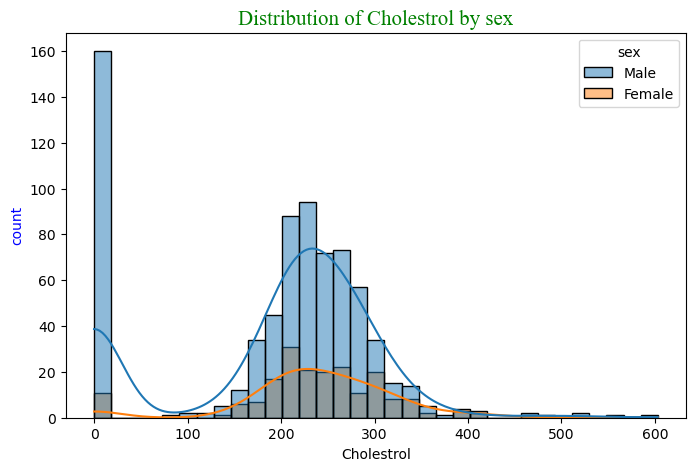

In [29]:
plt.figure(figsize=(8,5))
plt.title('Distribution of Cholestrol by sex', color='green', fontsize=15, family='Times New Roman')
plt.xlabel('Cholestrol', color='black', fontsize=10)
plt.ylabel('count', color='blue', fontsize=10)
sns.histplot(heart, x='chol', kde=True, hue='sex')

Frequency of chest pain by sex

<Axes: title={'center': 'Frequency of chest pain'}, xlabel='Chest Pain', ylabel='count'>

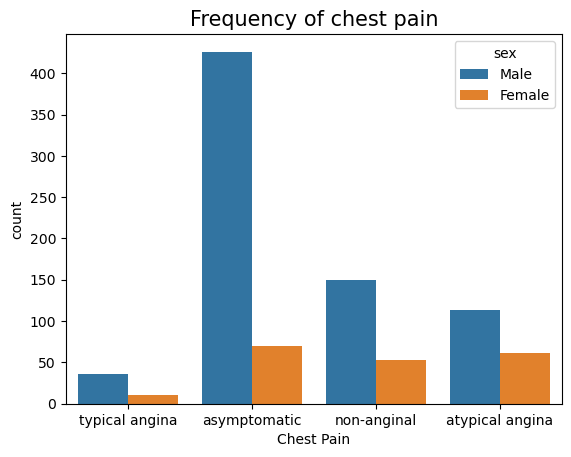

In [32]:
plt.title('Frequency of chest pain', size=15, color='black')
plt.xlabel('Chest Pain', color='black')
plt.ylabel('count', color='black')
sns.countplot(heart, x='cp', hue='sex')

Does age affect cholesterol?

<Axes: title={'center': 'Relationship between Age and Cholestrol'}, xlabel='Age', ylabel='Cholestrol'>

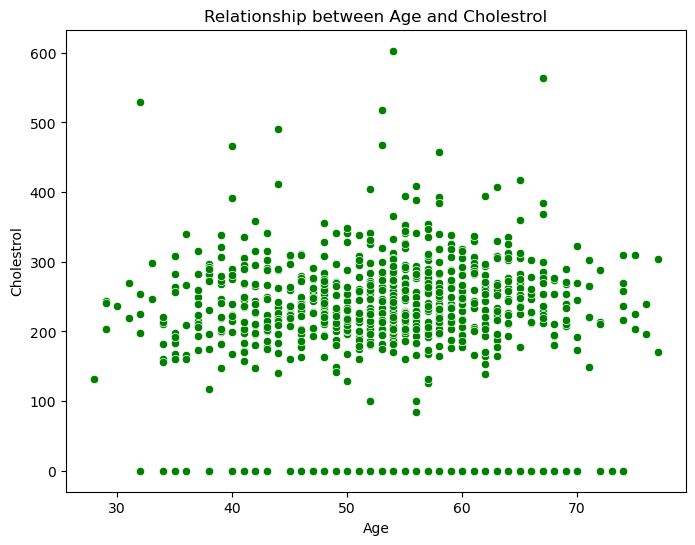

In [41]:
plt.figure(figsize=(8,6))
plt.title('Relationship between Age and Cholestrol')
plt.xlabel('Age')
plt.ylabel('Cholestrol')
sns.scatterplot(heart, x='age', y='chol', color='green')

Compare cholesterol levels between males and females

<Axes: title={'center': 'Cholesterol levels between males and females'}, xlabel='Sex', ylabel='Cholesterol levels'>

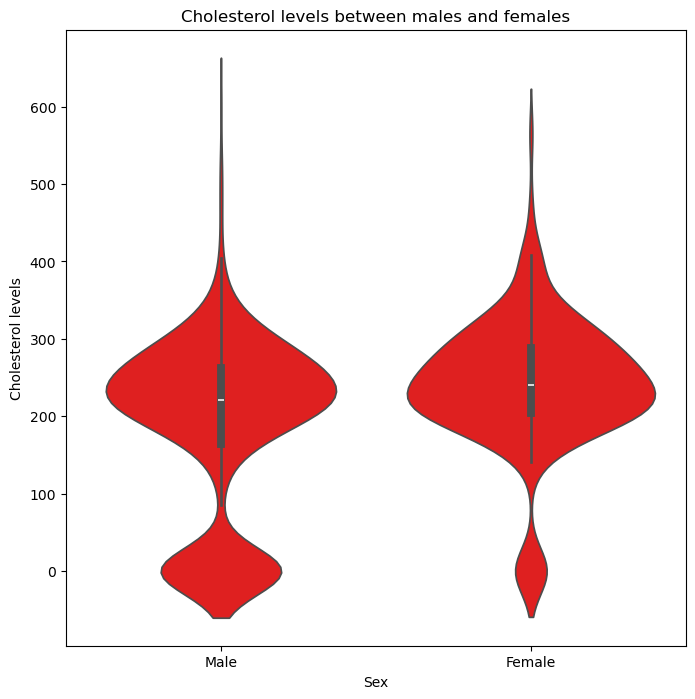

In [49]:
plt.figure(figsize=(8,8))
plt.title('Cholesterol levels between males and females')
plt.xlabel('Sex')
plt.ylabel('Cholesterol levels')
sns.violinplot(heart, x='sex',y='chol', color='red')

Compare maximum heart rate (thalch) for patients with and without exercise-induced angina (exang)

<Axes: title={'center': 'maximum heart rate (thalch) for patients with and without exercise-induced angina (exang)'}, xlabel='exang', ylabel='thalch'>

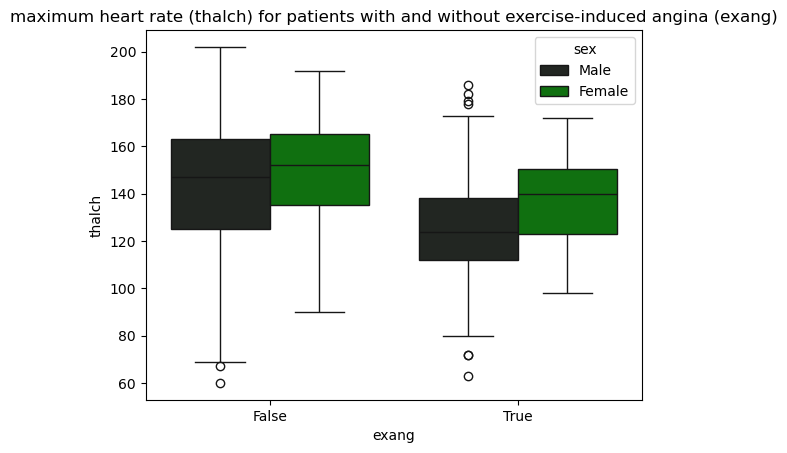

In [57]:
plt.title('maximum heart rate (thalch) for patients with and without exercise-induced angina (exang)')
sns.boxplot(heart, x='exang', y='thalch', palette='dark:green', hue='sex')

Which chest pain type has the highest average cholesterol?

In [78]:
avg_chol=heart.groupby(['cp'])['chol'].mean()
avg_chol.max()

233.57885057471265

Highest average cholesterol by chest pain value is 233.57885057471265


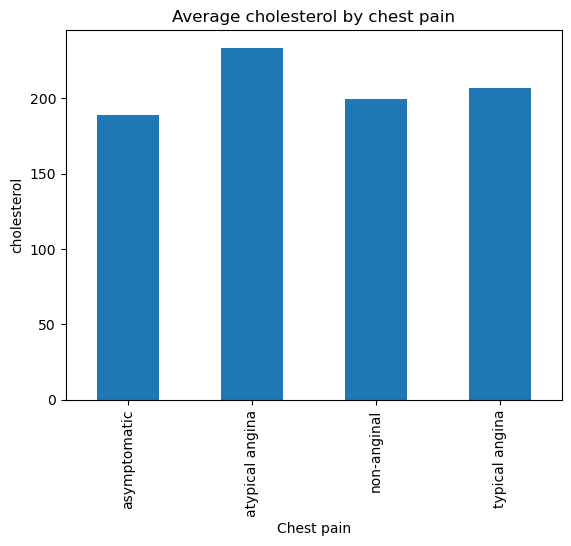

In [81]:
heart.groupby(['cp'])['chol'].mean().plot(kind='bar')
plt.title('Average cholesterol by chest pain')
plt.xlabel('Chest pain')
plt.ylabel('cholesterol')
print(f'Highest average cholesterol by chest pain value is {avg_chol.max()}')

Compare resting blood pressure (trestbps) across different chest pain types

<Axes: xlabel='cp', ylabel='trestbps'>

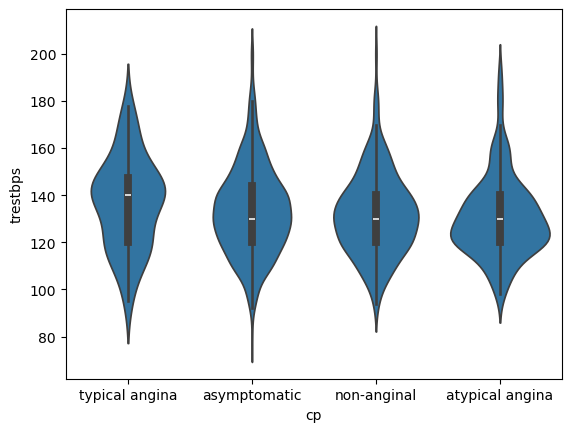

In [82]:
sns.violinplot(data=heart, x='cp', y='trestbps')

Create a correlation heatmap for all numerical columns

<Axes: >

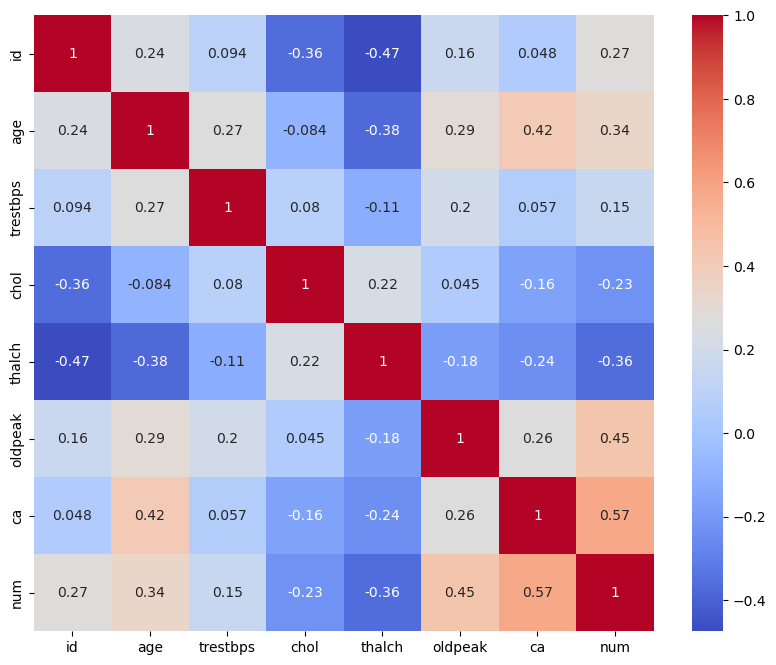

In [149]:
corr= heart.select_dtypes(include='number').corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')

Find out if oldpeak is related to thalch

<Axes: xlabel='oldpeak', ylabel='thalch'>

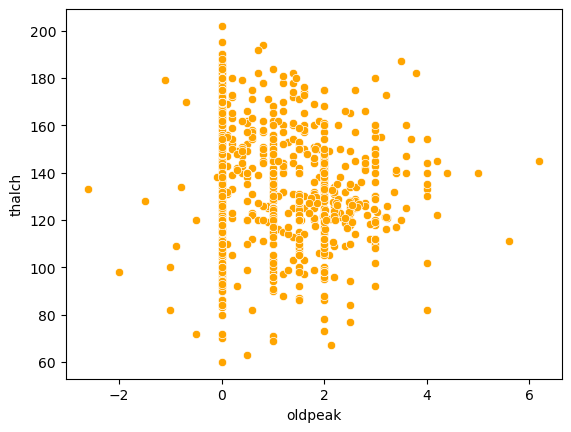

In [89]:
sns.scatterplot(data=heart, x='oldpeak', y='thalch', color='orange')

Visualize the relationship between age and resting blood pressure

<Axes: xlabel='age', ylabel='trestbps'>

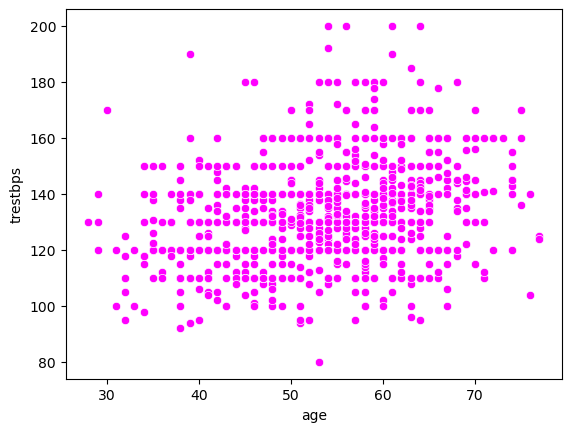

In [95]:
sns.scatterplot(data=heart, x='age', y='trestbps', color='magenta')

Compare the distribution of heart disease diagnosis (num)

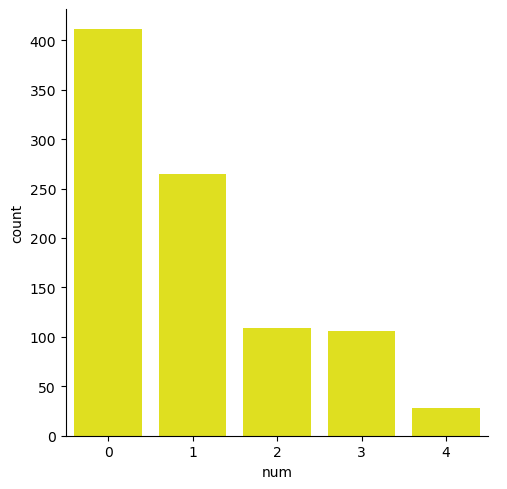

In [101]:
sns.catplot(heart, x='num', kind='count', color='yellow')

<Axes: xlabel='num', ylabel='Count'>

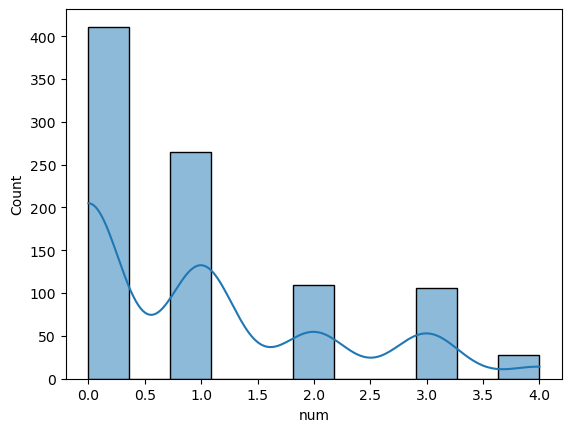

In [102]:
sns.histplot(heart, x='num', kde=True)

Compare cholesterol across each heart disease class (num)

<Axes: xlabel='num', ylabel='chol'>

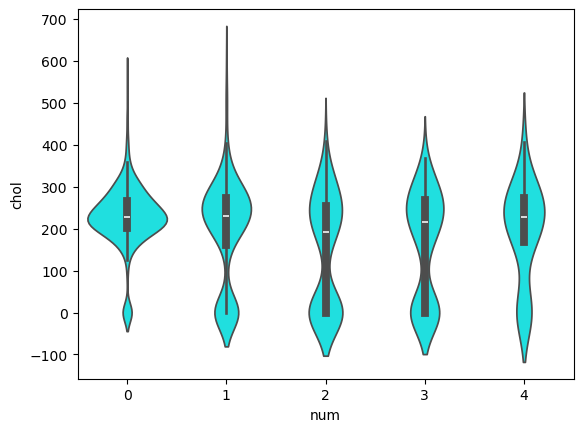

In [110]:
sns.violinplot(heart, x='num', y='chol',color='cyan')

Which age group has the highest number of heart disease cases?

Text(0.5, 1.0, 'Heart Disease Cases by Age Group')

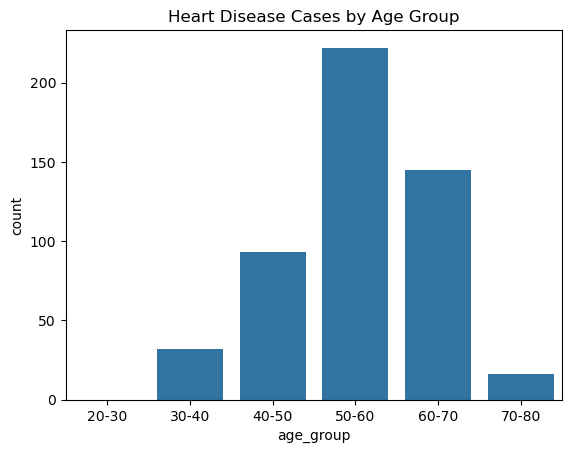

In [119]:
heart['age_group'] = pd.cut(
    heart['age'],
    bins=[20, 30, 40, 50, 60, 70, 80],
    labels=['20-30', '30-40', '40-50', '50-60', '60-70', '70-80']
)
heart_disease = heart[heart['num'] > 0]
heart_disease['age_group'].value_counts()

sns.countplot(data=heart_disease, x='age_group')
plt.title("Heart Disease Cases by Age Group")

Which chest pain type is most common among patients diagnosed with heart disease?

Number of patients affected by most common chest pain type is 392


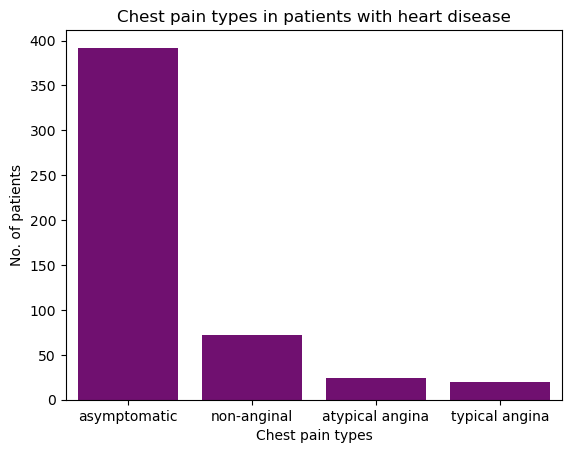

In [128]:
heart_disease = heart[heart['num'] > 0]
hd=heart_disease['cp'].value_counts()

sns.countplot(heart_disease, x='cp', color='purple')
plt.title('Chest pain types in patients with heart disease')
plt.xlabel('Chest pain types')
plt.ylabel('No. of patients')

print(f'Number of patients affected by most common chest pain type is {hd.max()}')

Does higher cholesterol always indicate heart disease?

<Axes: xlabel='num', ylabel='chol'>

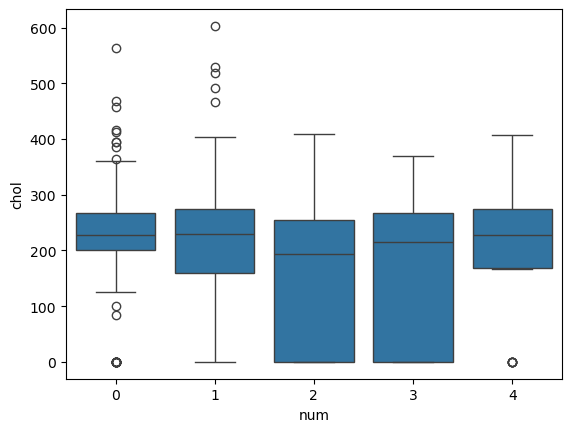

In [132]:
sns.boxplot(heart, y='chol', x='num')

Which numerical feature has the strongest correlation with num?

In [146]:
num=heart.select_dtypes(include='number')
corr=num.corr()
corr['num'].drop('num').abs().sort_values(ascending=False)

ca          0.574029
oldpeak     0.445811
thalch      0.363808
age         0.339868
id          0.272078
chol        0.226128
trestbps    0.147977
Name: num, dtype: float64